In [30]:
#Python v3.10.11
#Import necessary packages

import os
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import matplotlib.image as mpimg
import matplotlib as mpl

sys.path.append('functions')

from death_prediction_functions import time_to_death_grouped, cross_validation, train_nn, generate_nn_pred
from gene_analysis_functions import get_cistrome, get_pos, insig_nan

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
#set directory and get relevant files

os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/model_outputs')
death_pvals = pd.read_excel('death_classifier_probes.xlsx', index_col=0)
pinv_pvals = pd.read_excel('pseudoinverse_probes_filtered.xlsx', index_col=0)

In [32]:
#m12 blood glucose probes
GLU_probes_M12 = pinv_pvals['M10_poststress_GLU_pval']
GLU_probes_M12 = GLU_probes_M12.dropna()
GLU_probes_M12 = GLU_probes_M12[GLU_probes_M12<0.01]
GLU_probes_M12 = list(GLU_probes_M12.index)

print(f'Number of m10 blood glucose probes: {len(GLU_probes_M12)}')

#aging probes
age_probes = death_pvals
age_probes = age_probes.dropna()
age_probes = list(age_probes.index)

##

intersections = list(set(GLU_probes_M12) & set(age_probes))
cross_identified_probes = death_pvals.loc[intersections]
cross_identified_probes = cross_identified_probes[['coef', 'associated_genes']]

##

cross_identified_probes = cross_identified_probes.rename_axis('ID').reset_index()
cross_identified_probes

Number of m10 blood glucose probes: 46


,ID,coef,associated_genes
0,cg35547938_BC21,0.078439,"Pik3c3 (-3,266)"
1,cg32208789_TC21,0.022717,"Lrrc3b (+282,094), Nek10 (+353,478)"
2,cg32206002_BC21,0.063069,"Slc4a7 (-43,194), Olfr721-ps1 (+251,861)"
3,cg35891694_BC21,0.115852,"Mbd2 (-20,881), Poli (-16,688)"
4,cg37125936_BC11,0.072501,"Kcne4 (-144,585), Utp14b (+14,135)"
5,cg34900994_TC21,0.008584,"Olfr761 (+8,467), Olfr128 (+24,064)"
6,cg33480444_BC22,0.049532,"Gm6569 (-24,652), Ptp4a3 (+84,979)"
7,cg33524962_BC21,-0.022253,"Apol7c (+5,203), Apol11a (+19,841)"
8,cg33482097_TC21,0.124430,"Adgrb1 (-548,371), Mroh5 (-128,153)"
9,cg33479240_BC21,-0.058070,Ptp4a3 (-304)


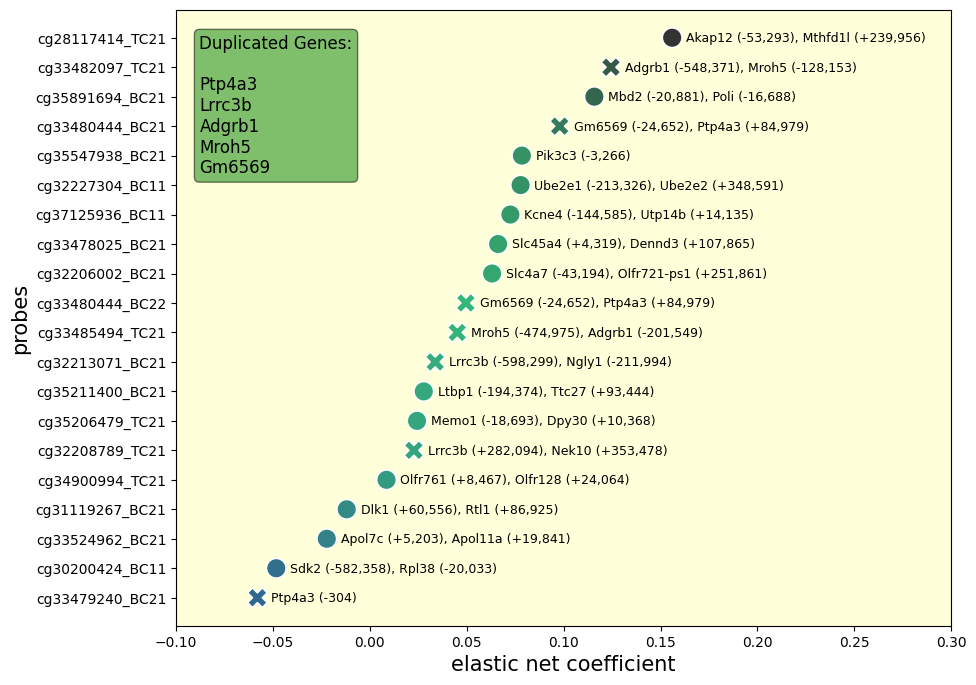

In [33]:
#extract genes from associated_genes column
def extract_genes(gene_string):

    genes = []
    n_genes = gene_string.count(', ')
    n = 0

    while n < n_genes+1:
        index_space = gene_string.find(' ')
        gene_n = gene_string[:index_space]
        genes.append(gene_n)

        index_comma = gene_string.find(', ')
        gene_string = gene_string[index_comma+2:]

        n+=1

    return genes

#sort elastic net by value so the legend isn't obscured
cross_identified_probes = cross_identified_probes.sort_values(by='coef', ascending=False, ignore_index=True)

#apply the function to each entry in 'associated_genes' column
associated_genes_full = [gene for gene in cross_identified_probes['associated_genes']]
cross_identified_probes['genes'] = cross_identified_probes['associated_genes'].apply(extract_genes)

#count occurrences of each gene across all entries
gene_counts = pd.Series([gene for genes_list in cross_identified_probes['genes'] for gene in genes_list]).value_counts()

#define marker style based on duplication status
duplicates = gene_counts[gene_counts > 1].index.tolist()

marker_style = []
for genes in cross_identified_probes['associated_genes']:
    to_append = '^'
    for gene in duplicates:
        if gene in genes:
            to_append = 'o'
        else: pass
    marker_style.append(to_append)
    
#create the scatterplot with emphasized duplicated genes
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=cross_identified_probes, x='coef', y='ID', style=marker_style, s=200, 
                legend=False, palette='viridis_d', hue='coef')

#add legend showing repeated genes
props = dict(boxstyle='round', facecolor='green', alpha=0.5)

gene_list_formatted = '\n'.join(duplicates)
plt.text(0.03, 0.96, f'Duplicated Genes:\n\n{gene_list_formatted}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

#annotate each point with associated genes
for i, genes in enumerate(associated_genes_full):
    x = cross_identified_probes['coef'][i]
    y = cross_identified_probes.index[i]
    ax.annotate(genes, (x, y), textcoords="offset points", xytext=(10, -3), ha='left', size=9)

plt.xlabel('elastic net coefficient', size=15)
plt.ylabel('probes', size=15)

ax.set_facecolor((1, 1, 0.8509803921)) #same as plot included in same figure
plt.xlim(-0.1, 0.3)

plt.show() #only 4 selected for M12